DiscovAI — Drug Discovery Pipeline
Target: BCL2 (CHEMBL3038)
Step 1 — Fetching 20 molecules from ChEMBL...
         13 molecules retrieved
Step 2 — Calculating molecular properties...
Step 3 — Applying Lipinski filter...
         13 drug-like molecules remaining
Step 4 — ADMET scoring...
Step 5 — Computing DiscovAI global score...
RESULTS — Top drug candidates
 molecule_id  IC50_nM  admet_score  discovai_score absorption distribution metabolism toxicity
CHEMBL150332     13.0           80            77.8  Excellent         Good   Moderate Low risk
CHEMBL151284  50000.0           90            36.0  Excellent         Good     Stable Low risk
 CHEMBL33352  50000.0           90            36.0  Excellent         Good     Stable Low risk
CHEMBL356252  50000.0           75            30.0  Excellent         Poor     Stable Low risk
CHEMBL302067  50000.0           75            30.0  Excellent         Poor     Stable Low risk

Step 6 — Visualizing top candidates...


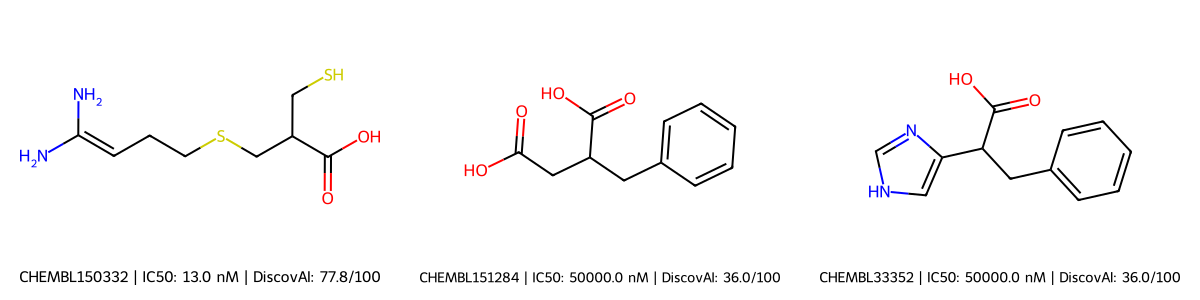


Best candidate: CHEMBL150332
IC50           : 13.0 nM
DiscovAI score : 77.8/100


In [1]:
# DiscovAI — AI-Powered Drug Discovery Pipeline
# Author: [Votre nom]
# Target: BCL2 (CHEMBL3038) — Anti-apoptotic protein involved in cancer
# Version: 0.1

# ============================================================
# IMPORTS
# ============================================================

import requests
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, Draw
from IPython.display import display

# ============================================================
# STEP 1 — FETCH MOLECULES FROM CHEMBL
# ============================================================

def fetch_molecules(target_id, n=20):
    """Fetch active molecules against a target from ChEMBL database"""
    url = "https://www.ebi.ac.uk/chembl/api/data/activity"
    params = {
        'target_chembl_id': target_id,
        'standard_type': 'IC50',
        'limit': n,
        'format': 'json'
    }
    response = requests.get(url, params=params)
    data = response.json()
    results = []
    for activity in data['activities']:
        results.append({
            'molecule_id': activity['molecule_chembl_id'],
            'IC50_nM': activity['standard_value'],
            'smiles': activity['canonical_smiles']
        })
    return pd.DataFrame(results).dropna(subset=['smiles', 'IC50_nM'])

# ============================================================
# STEP 2 — CALCULATE MOLECULAR PROPERTIES
# ============================================================

def calculate_properties(smiles):
    """Calculate key physicochemical properties using RDKit"""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return pd.Series({
        'mol_weight': round(Descriptors.MolWt(mol), 2),
        'logP': round(Descriptors.MolLogP(mol), 2),
        'hbd': rdMolDescriptors.CalcNumHBD(mol),
        'hba': rdMolDescriptors.CalcNumHBA(mol),
        'tpsa': round(rdMolDescriptors.CalcTPSA(mol), 2),
        'rot_bonds': rdMolDescriptors.CalcNumRotatableBonds(mol),
        'rings': rdMolDescriptors.CalcNumRings(mol)
    })

# ============================================================
# STEP 3 — LIPINSKI FILTER
# ============================================================

def lipinski_filter(row):
    """Apply Lipinski Rule of Five — standard drug-likeness filter"""
    conditions = [
        row['mol_weight'] <= 500,
        row['logP'] <= 5,
        row['hbd'] <= 5,
        row['hba'] <= 10
    ]
    score = sum(conditions)
    return pd.Series({
        'lipinski_score': score,
        'drug_like': score == 4
    })

# ============================================================
# STEP 4 — ADMET SCORING
# ============================================================

def admet_score(row):
    """Score molecule on Absorption, Distribution, Metabolism, Toxicity"""
    score = 0

    # Absorption — optimal LogP between 0 and 3
    if 0 <= row['logP'] <= 3:
        score += 25
        absorption = 'Excellent'
    elif -1 <= row['logP'] <= 5:
        score += 15
        absorption = 'Good'
    else:
        absorption = 'Poor'

    # Distribution — Polar Surface Area
    if row['tpsa'] <= 60:
        score += 25
        distribution = 'Excellent'
    elif row['tpsa'] <= 90:
        score += 15
        distribution = 'Good'
    else:
        distribution = 'Poor'

    # Metabolism — rotatable bonds
    if row['rot_bonds'] <= 5:
        score += 25
        metabolism = 'Stable'
    elif row['rot_bonds'] <= 8:
        score += 15
        metabolism = 'Moderate'
    else:
        metabolism = 'Unstable'

    # Toxicity — molecular weight + ring count
    if row['mol_weight'] <= 400 and row['rings'] <= 3:
        score += 25
        toxicity = 'Low risk'
    elif row['mol_weight'] <= 500 and row['rings'] <= 4:
        score += 15
        toxicity = 'Moderate risk'
    else:
        toxicity = 'High risk'

    return pd.Series({
        'admet_score': score,
        'absorption': absorption,
        'distribution': distribution,
        'metabolism': metabolism,
        'toxicity': toxicity
    })

# ============================================================
# STEP 5 — GLOBAL DISCOVAI SCORE
# ============================================================

def discovai_score(row):
    """
    Combined DiscovAI score — 60% efficacy (IC50) + 40% ADMET
    Higher is better. Range: 0-100.
    """
    ic50 = pd.to_numeric(row['IC50_nM'], errors='coerce')
    if pd.isna(ic50) or ic50 == 0:
        efficacy_score = 0
    else:
        efficacy_score = max(0, 100 - (np.log10(ic50) / np.log10(50000)) * 100)
    return round((efficacy_score * 0.6) + (row['admet_score'] * 0.4), 1)

# ============================================================
# STEP 6 — VISUALIZATION
# ============================================================

def visualize_candidates(df, n=3):
    """Display 2D molecular structures of top candidates"""
    mols, legends = [], []
    for _, row in df.head(n).iterrows():
        mol = Chem.MolFromSmiles(row['smiles'])
        if mol:
            mols.append(mol)
            legends.append(
                f"{row['molecule_id']} | IC50: {row['IC50_nM']} nM | DiscovAI: {row['discovai_score']}/100"
            )
    img = Draw.MolsToGridImage(
        mols,
        molsPerRow=3,
        subImgSize=(400, 300),
        legends=legends,
        returnPNG=False
    )
    img.save('discovai_results.png')
    display(img)

# ============================================================
# MAIN PIPELINE
# ============================================================

def run_discovai(target_id, target_name, n_molecules=20):
    """
    Run the full DiscovAI pipeline on a given ChEMBL target.
    
    Parameters:
        target_id    : ChEMBL target ID (e.g. 'CHEMBL3038')
        target_name  : Human-readable target name (e.g. 'BCL2')
        n_molecules  : Number of molecules to retrieve
    
    Returns:
        DataFrame of ranked drug candidates
    """
    print(f"DiscovAI — Drug Discovery Pipeline")
    print(f"Target: {target_name} ({target_id})")
    print("=" * 55)

    # Fetch
    print(f"Step 1 — Fetching {n_molecules} molecules from ChEMBL...")
    df = fetch_molecules(target_id, n_molecules)
    print(f"         {len(df)} molecules retrieved")

    # Properties
    print("Step 2 — Calculating molecular properties...")
    props = df['smiles'].apply(calculate_properties)
    df = pd.concat([df.reset_index(drop=True), props], axis=1).dropna()

    # Lipinski
    print("Step 3 — Applying Lipinski filter...")
    lipinski = df.apply(lipinski_filter, axis=1)
    df = pd.concat([df, lipinski], axis=1)
    df = df[df['drug_like'] == True]
    print(f"         {len(df)} drug-like molecules remaining")

    # ADMET
    print("Step 4 — ADMET scoring...")
    admet = df.apply(admet_score, axis=1)
    df = pd.concat([df.reset_index(drop=True), admet], axis=1)

    # Global score
    print("Step 5 — Computing DiscovAI global score...")
    df['IC50_nM'] = pd.to_numeric(df['IC50_nM'], errors='coerce')
    df['discovai_score'] = df.apply(discovai_score, axis=1)
    df = df.sort_values('discovai_score', ascending=False).reset_index(drop=True)

    # Results
    print("=" * 55)
    print("RESULTS — Top drug candidates")
    print(df[['molecule_id', 'IC50_nM', 'admet_score', 
              'discovai_score', 'absorption', 
              'distribution', 'metabolism', 'toxicity']].head(5).to_string(index=False))

    # Visualization
    print("\nStep 6 — Visualizing top candidates...")
    visualize_candidates(df, n=3)

    print(f"\nBest candidate: {df.iloc[0]['molecule_id']}")
    print(f"IC50           : {df.iloc[0]['IC50_nM']} nM")
    print(f"DiscovAI score : {df.iloc[0]['discovai_score']}/100")

    return df

# ============================================================
# RUN
# ============================================================

results = run_discovai(
    target_id='CHEMBL3038',
    target_name='BCL2',
    n_molecules=20
)